In [ ]:
# write code to calculate accuracy in cunfusion matrix
import numpy as np


In [ ]:
confusion_matrix = [[50,10],
                    [5,35]]
tp = confusion_matrix[0][0]
fp = confusion_matrix[0][1]
fn = confusion_matrix[1][0]
tn = confusion_matrix[1][1]
accuracy = (tp+tn)/(tp+tn+fp+fn)
precision = tp/(tp+fp)
recall = tp/(tp+fn)
f1_score = 2*precision*recall/(precision+recall)
print(accuracy, precision, recall, f1_score)

0.85 0.8333333333333334 0.9090909090909091 0.8695652173913043


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

In [ ]:
(ds_train, ds_test), ds_info = tfds.load(
    'mnist',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

Dl Completed...:   0%|          | 0/5 [00:00<?, ? file/s]

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [ ]:
import matplotlib.pyplot as plt

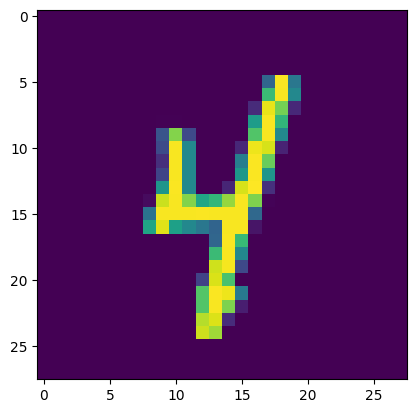

tf.Tensor(4, shape=(), dtype=int64)


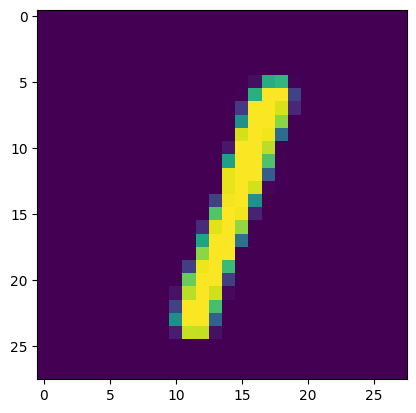

tf.Tensor(1, shape=(), dtype=int64)


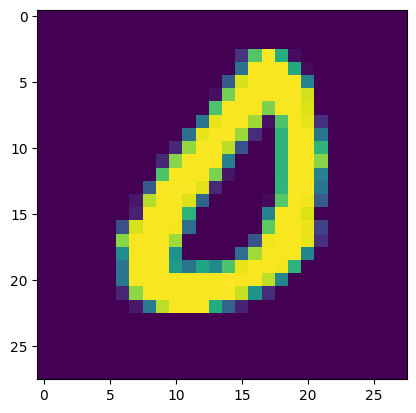

tf.Tensor(0, shape=(), dtype=int64)


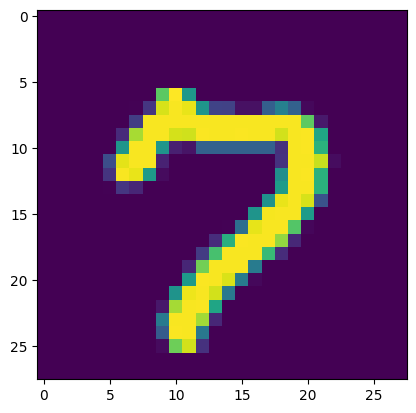

tf.Tensor(7, shape=(), dtype=int64)


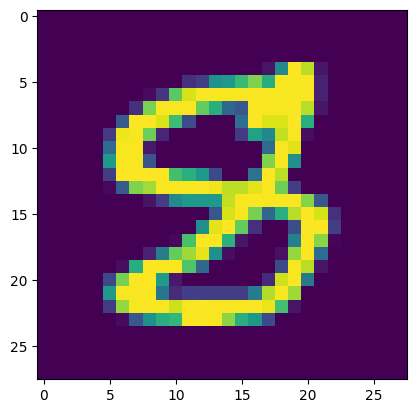

tf.Tensor(8, shape=(), dtype=int64)


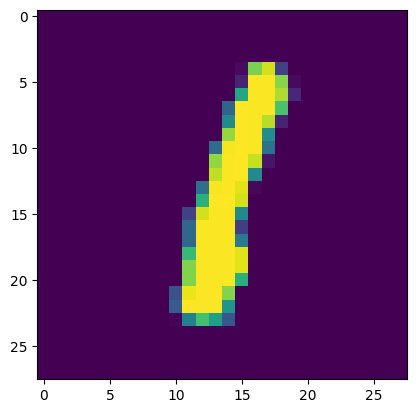

tf.Tensor(1, shape=(), dtype=int64)


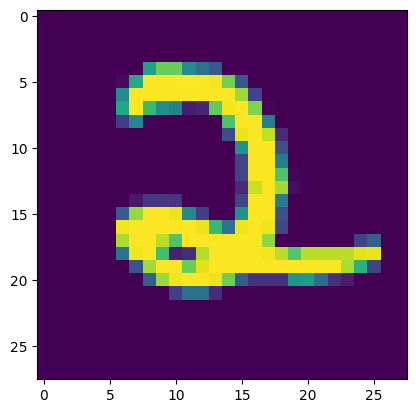

tf.Tensor(2, shape=(), dtype=int64)


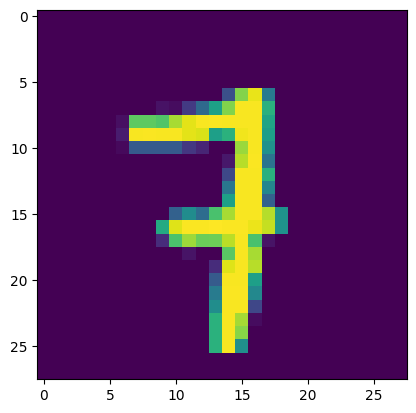

tf.Tensor(7, shape=(), dtype=int64)


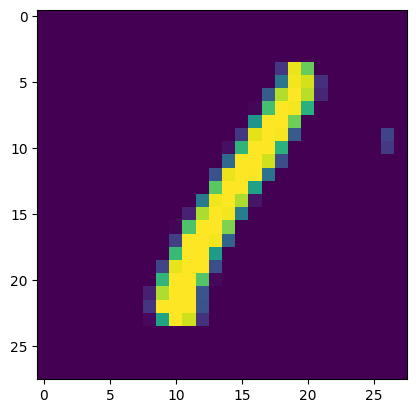

tf.Tensor(1, shape=(), dtype=int64)


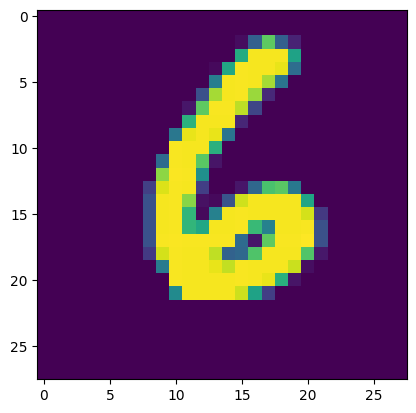

tf.Tensor(6, shape=(), dtype=int64)


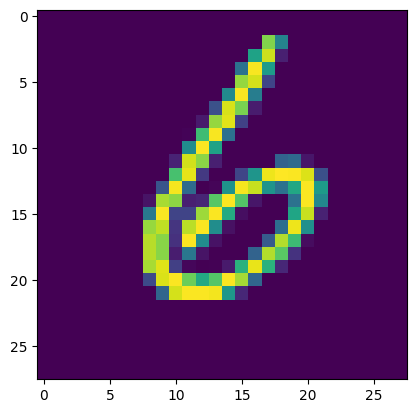

tf.Tensor(6, shape=(), dtype=int64)


In [ ]:
for i, (img, label) in enumerate(ds_train):
  plt.imshow(img)
  plt.show()
  print(label)
  if i == 10:
    break

In [ ]:
def normalize_img(image, label):
  cast_img = tf.cast(image, tf.float32) /255.
  return cast_img, label

In [ ]:
for i, (img, label) in enumerate(ds_train):
  image, label = normalize_img(img, label)
  print(image.shape)
  print(label)
  break

(28, 28, 1)
tf.Tensor(4, shape=(), dtype=int64)


In [ ]:
ds_train = ds_train.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_train = ds_train.batch(128)
ds_train = ds_train.cache()
ds_train = ds_train.prefetch(tf.data.AUTOTUNE)

In [ ]:
ds_test = ds_test.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.batch(1)
ds_test = ds_test.cache()
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)

In [ ]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(256, activation='relu'),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary

<bound method Model.summary of <Sequential name=sequential, built=True>>

In [ ]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
optimizer = tf.keras.optimizers.Adam()

In [ ]:
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

In [ ]:
history = model.fit(ds_train, epochs=20, validation_data=ds_test)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 58ms/step - accuracy: 0.8412 - loss: 0.5450 - val_accuracy: 0.9595 - val_loss: 0.1376
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 42ms/step - accuracy: 0.9631 - loss: 0.1222 - val_accuracy: 0.9713 - val_loss: 0.0960
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.9751 - loss: 0.0825 - val_accuracy: 0.9737 - val_loss: 0.0840
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.9812 - loss: 0.0619 - val_accuracy: 0.9724 - val_loss: 0.0874
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9855 - loss: 0.0468 - val_accuracy: 0.9721 - val_loss: 0.0929
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9889 - loss: 0.0346 - val_accuracy: 0.9739 - val_loss: 0.0972
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.9913 - loss: 0.0288 - val_accuracy: 0.9738 - val_loss: 0.0936
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9923 - loss: 0.0246 - 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step
Model Predict: [2]
Actual value: [2]


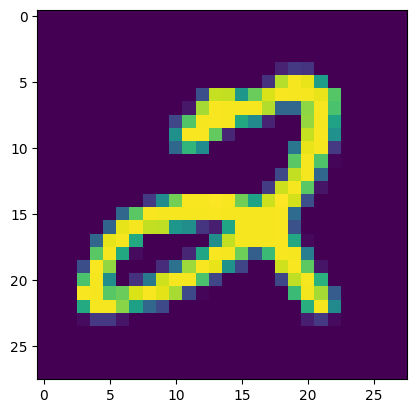

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Model Predict: [0]
Actual value: [0]


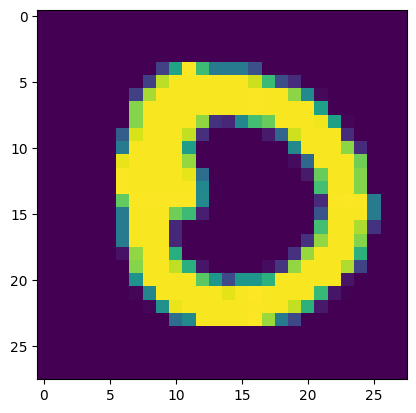

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Model Predict: [4]
Actual value: [4]


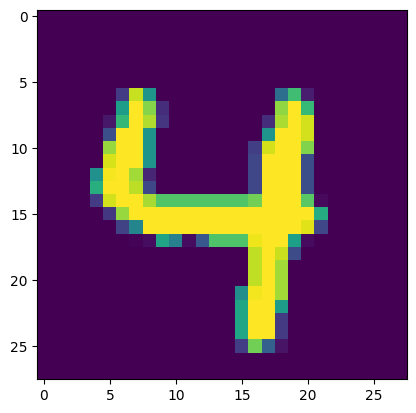

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Model Predict: [8]
Actual value: [8]


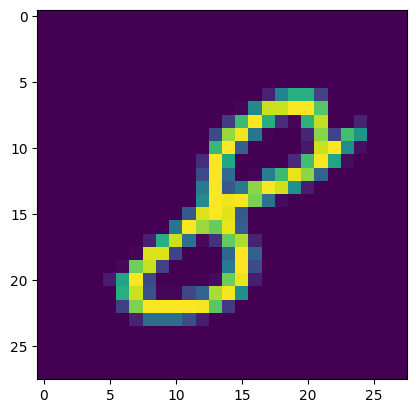

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Model Predict: [7]
Actual value: [7]


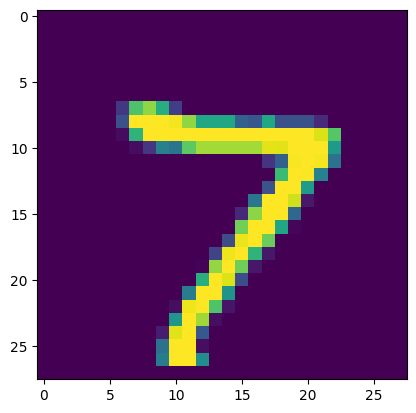

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Model Predict: [6]
Actual value: [6]


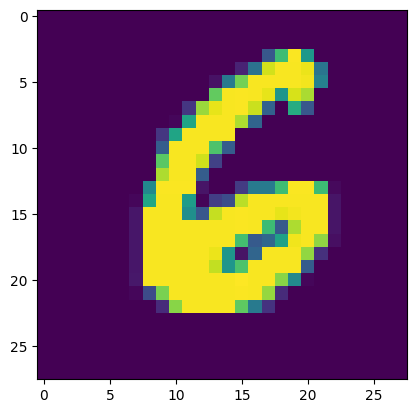

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Model Predict: [0]
Actual value: [0]


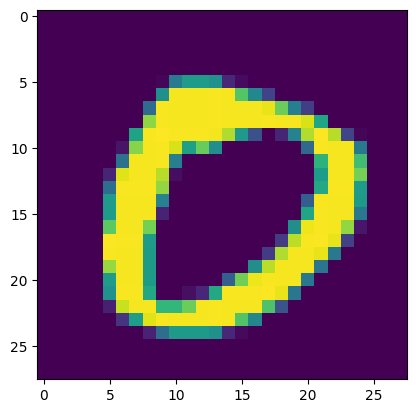

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Model Predict: [6]
Actual value: [6]


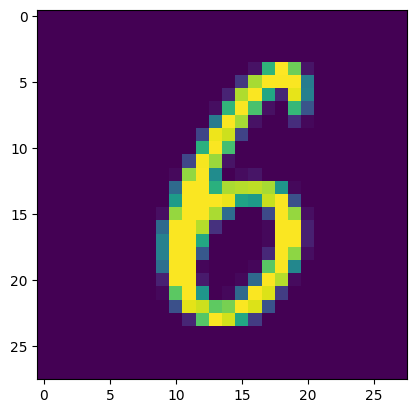

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Model Predict: [3]
Actual value: [3]


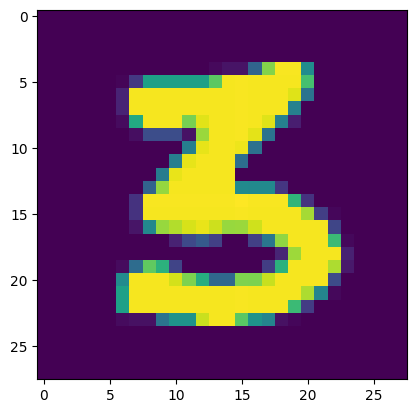

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Model Predict: [1]
Actual value: [1]


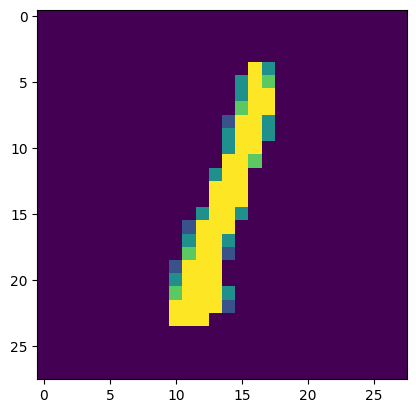

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Model Predict: [8]
Actual value: [8]


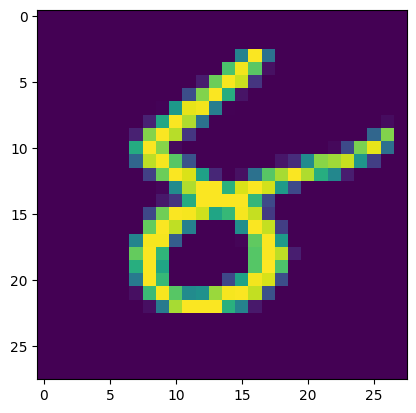

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Model Predict: [0]
Actual value: [0]


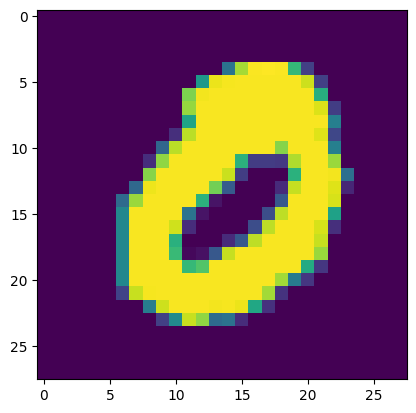

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Model Predict: [7]
Actual value: [7]


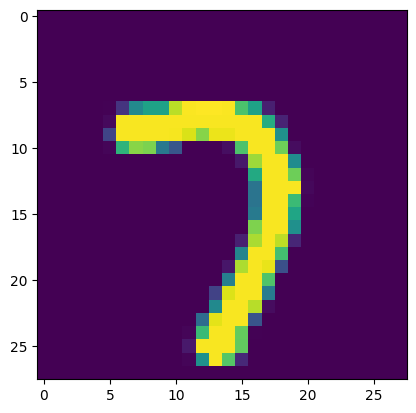

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Model Predict: [9]
Actual value: [9]


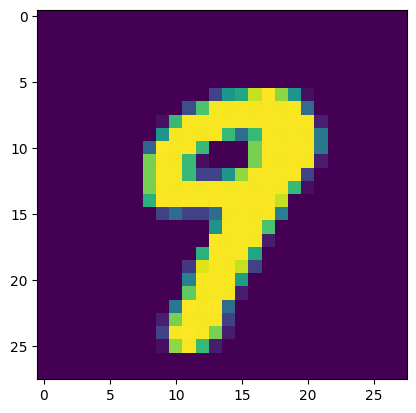

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Model Predict: [8]
Actual value: [8]


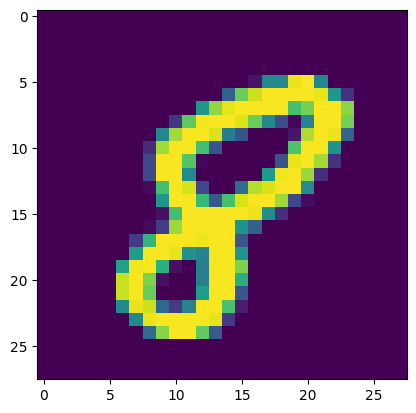

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Model Predict: [4]
Actual value: [4]


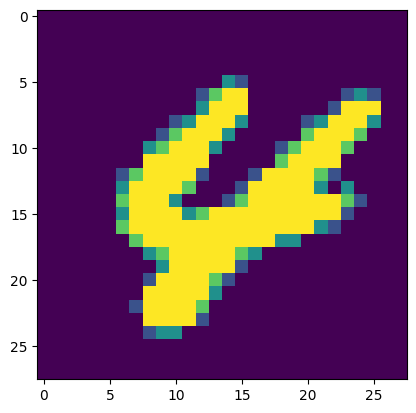

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Model Predict: [5]
Actual value: [5]


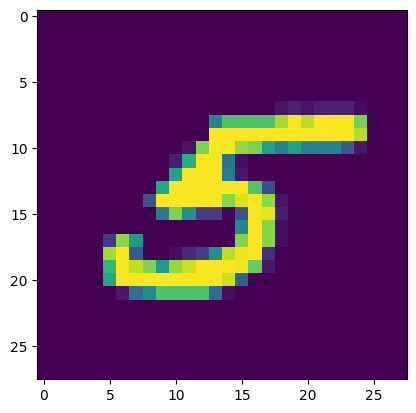

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Model Predict: [3]
Actual value: [3]


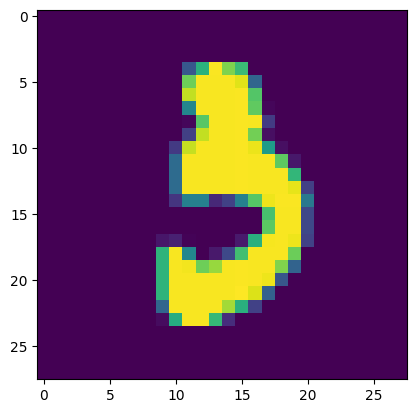

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Model Predict: [4]
Actual value: [4]


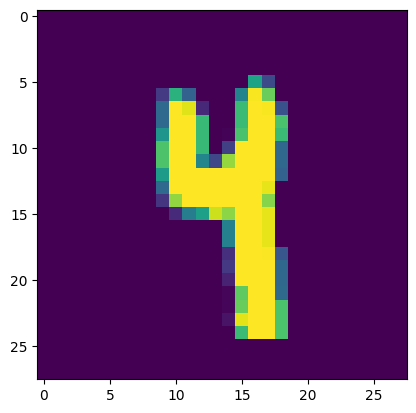

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Model Predict: [0]
Actual value: [0]


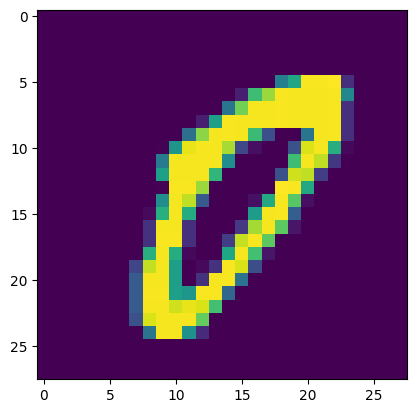

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Model Predict: [6]
Actual value: [6]


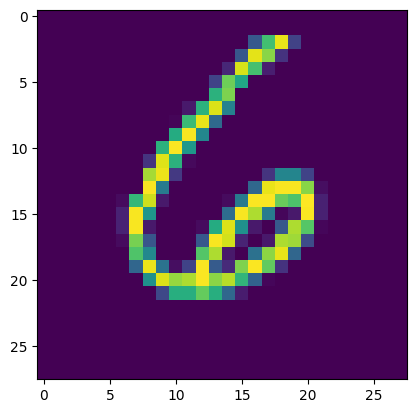

In [ ]:
for i, (img, label) in enumerate(ds_test):
  pred = model.predict(img)
  pred = tf.argmax(pred, axis=1)
  print("Model Predict:", pred.numpy())
  print("Actual value:", label.numpy())
  plt.imshow(img[0,:,:,:])
  plt.show()
  if i == 20:
    break

Training model using CNN

In [ ]:
model = tf.keras.models.Sequential([
       tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
       tf.keras.layers.MaxPooling2D((2, 2)),
       tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
       tf.keras.layers.MaxPooling2D((2, 2)),
       tf.keras.layers.Flatten(),
       tf.keras.layers.Dense(10, activation='softmax')
   ])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

In [ ]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
optimizer = tf.keras.optimizers.Adam()
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

In [ ]:
history = model.fit(ds_train, epochs=20, validation_data=ds_test)  # Adjust epochs as needed

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.8130 - loss: 0.6489 - val_accuracy: 0.9748 - val_loss: 0.0825
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step - accuracy: 0.9753 - loss: 0.0834 - val_accuracy: 0.9806 - val_loss: 0.0586
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9814 - loss: 0.0608 - val_accuracy: 0.9824 - val_loss: 0.0545
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.9849 - loss: 0.0492 - val_accuracy: 0.9827 - val_loss: 0.0495
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.9873 - loss: 0.0415 - val_accuracy: 0.9849 - val_loss: 0.0452
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 46ms/step - accuracy: 0.9891 - loss: 0.0360 - val_accuracy: 0.9864 - val_loss: 0.0414
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.9912 - loss: 0.0311 - val_accuracy: 0.9878 - val_loss: 0.0393
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.9923 - loss: 0.0270 - 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Model Predict: [2]
Actual value: [2]


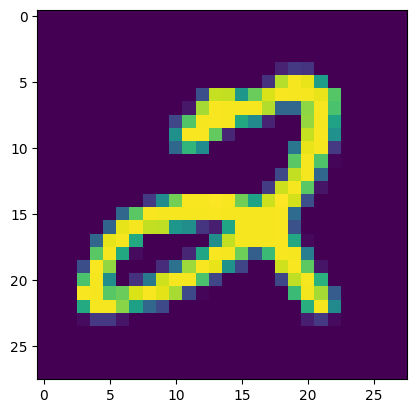

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Model Predict: [0]
Actual value: [0]


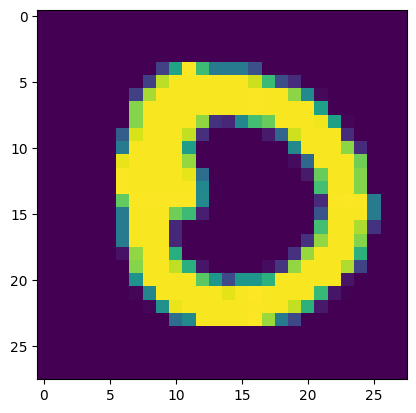

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Model Predict: [4]
Actual value: [4]


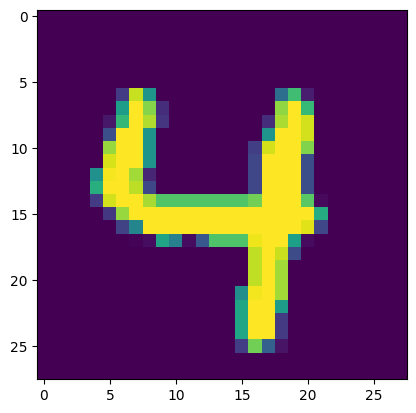

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Model Predict: [8]
Actual value: [8]


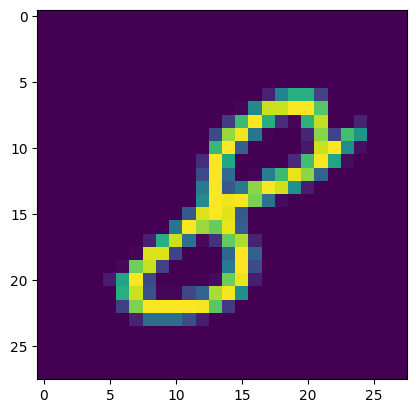

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Model Predict: [7]
Actual value: [7]


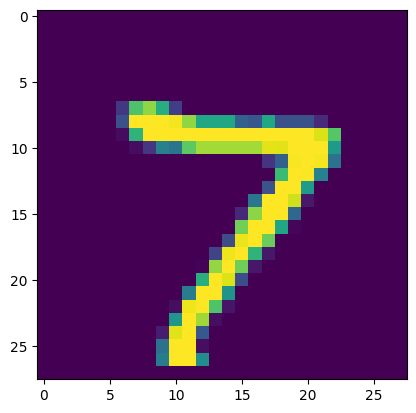

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Model Predict: [6]
Actual value: [6]


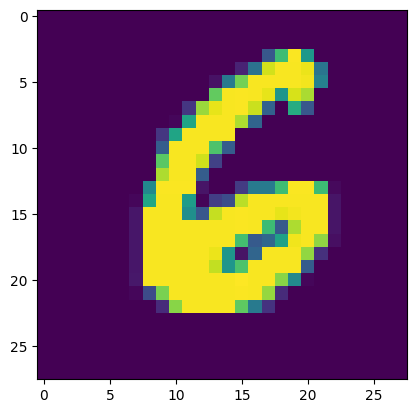

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Model Predict: [0]
Actual value: [0]


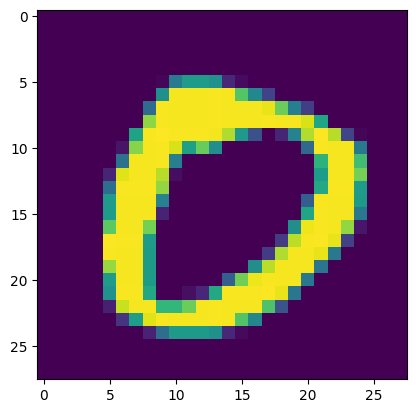

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Model Predict: [6]
Actual value: [6]


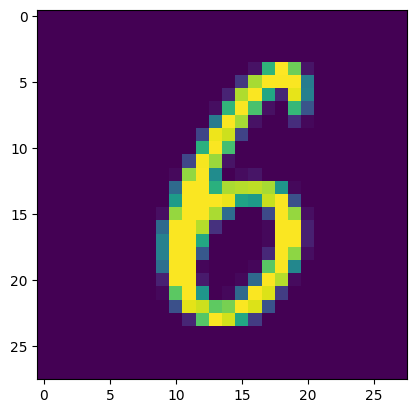

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Model Predict: [3]
Actual value: [3]


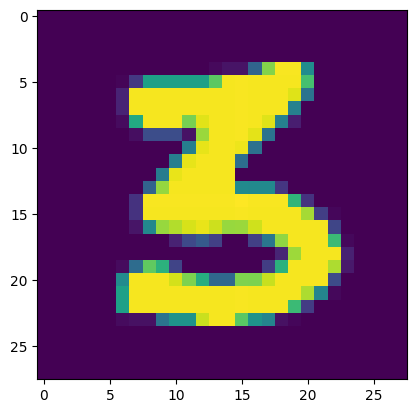

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Model Predict: [1]
Actual value: [1]


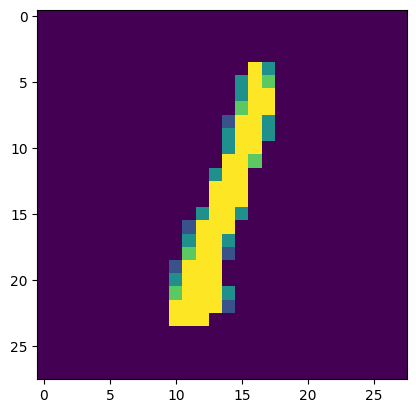

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Model Predict: [8]
Actual value: [8]


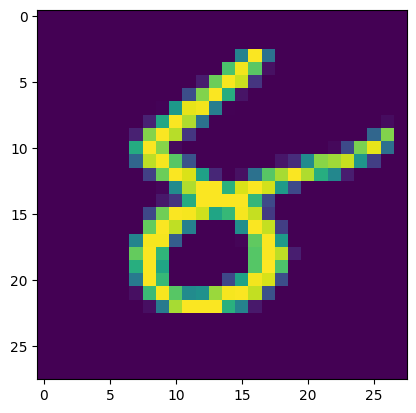

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Model Predict: [0]
Actual value: [0]


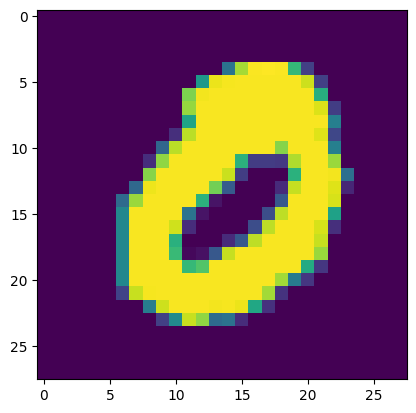

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Model Predict: [7]
Actual value: [7]


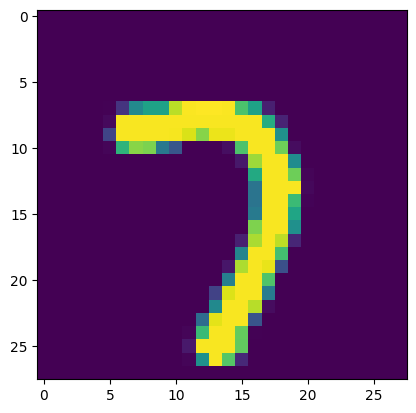

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Model Predict: [9]
Actual value: [9]


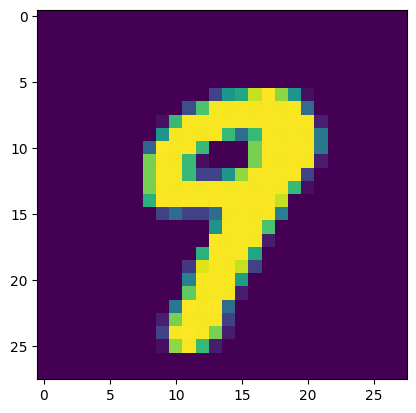

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Model Predict: [8]
Actual value: [8]


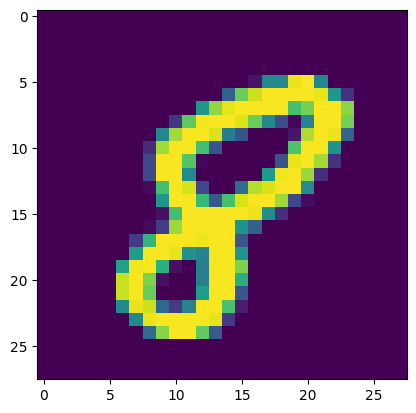

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Model Predict: [4]
Actual value: [4]


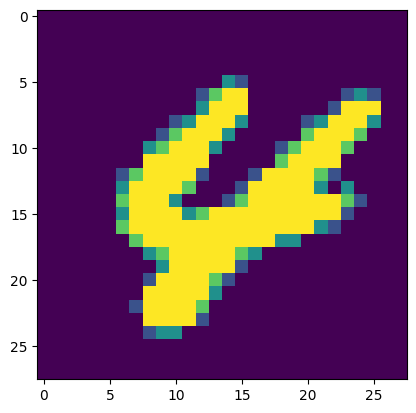

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Model Predict: [5]
Actual value: [5]


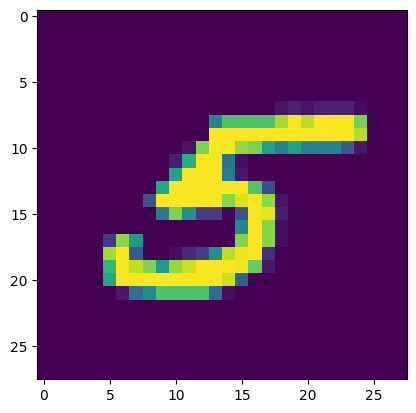

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Model Predict: [3]
Actual value: [3]


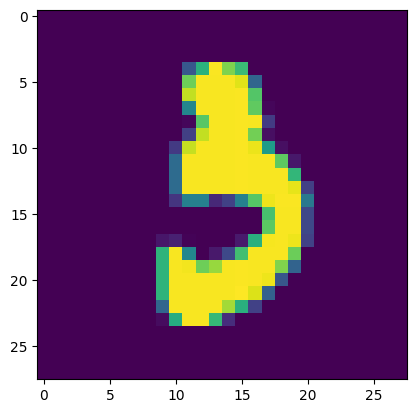

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Model Predict: [4]
Actual value: [4]


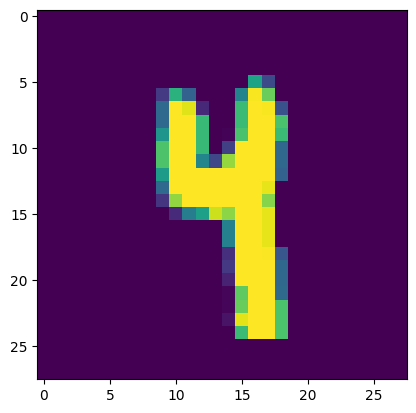

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Model Predict: [0]
Actual value: [0]


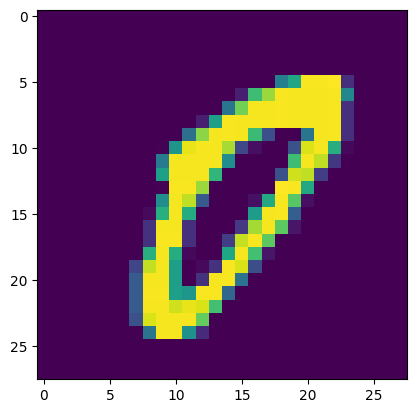

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Model Predict: [6]
Actual value: [6]


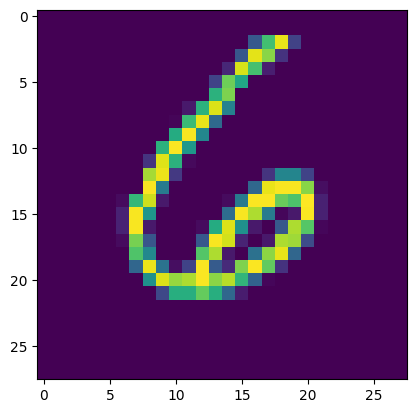

In [ ]:
for i, (img, label) in enumerate(ds_test):
     pred = model.predict(img)
     pred = tf.argmax(pred, axis=1)
     print("Model Predict:", pred.numpy())
     print("Actual value:", label.numpy())
     plt.imshow(img[0,:,:,:])
     plt.show()
     if i == 20:
       break